# Firing-Rate Decoding: Space vs Time

**Goal**: Use simple OLS linear regression to decode **angular position** (space) and **elapsed time** from firing rates across all recordings. Compare decoding performance (cross-validated R²) across run types (fam1, fam2, nov, fam1rev).

**Hypothesis**: fam2 firing rates encode space less well than fam1, and may instead carry more temporal (drift) information.

**Method**: 5-fold shuffled cross-validation with RidgeCV (auto-tuned α from 0.1 to 10 000) — a regularised linear model that prevents overfitting while remaining fully interpretable. Shuffled CV tests the static firing-rate ↔ variable relationship; temporal autocorrelation inflates absolute R² equally for all run types, so the **relative** comparison remains valid.\n- **Space**: predict `[sin φ, cos φ]` from firing rates → R² and mean angular error\n- **Time**: predict normalised time (0→1) from firing rates → R²

In [13]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold

from remapping.dataset import MiceDataset, Animals, GROUP_ORDER
from remapping.plotting import BehaviorColors, PlotStyle, get_figures_path
from remapping.metrics import r_squared

mice = MiceDataset()
colors = BehaviorColors()
style = PlotStyle()
palette = mice.get_group_palette()


def annotate_violins(ax, data, x, y, order, width=0.15):
    """Overlay Q1/Q3 lines, median line, and mean diamond on violin plots."""
    for i, cat in enumerate(order):
        vals = data.loc[data[x] == cat, y].dropna()
        if len(vals) == 0:
            continue
        q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
        mean_val = vals.mean()
        ax.hlines([q1, q3], i - width, i + width, color="k", linewidth=0.8, zorder=3)
        ax.hlines(med, i - width, i + width, color="k", linewidth=1.5, zorder=3)
        ax.scatter(i, mean_val, marker="D", color="white", edgecolors="k",
                   s=14, linewidths=0.8, zorder=4)

In [14]:
# --- Parameters ---

# Processing pipeline
ONLY_MOVING = True
BINS_COMPRESS = 3
BINS_SMOOTHING = 3
BINS_PHI = 360
MIN_NEURONS = 30

# Ridge alphas to search (log-spaced)
RIDGE_ALPHAS = np.logspace(-1, 4, 20)  # 0.1 to 10_000
N_FOLDS = 5  # contiguous temporal blocks

# Run-type mapping: fam1r2 grouped with fam1
RUN_TYPE_MAP = {
    "fam1": "fam1",
    "fam2": "fam2",
    "nov": "nov",
    "fam1rev": "fam1rev",
    "fam1r2": "fam1",
}
RUN_TYPE_ORDER = ["fam1", "fam2", "nov", "fam1rev"]
RUN_TYPE_COLORS = {
    "fam1": "#e85d04",
    "fam2": "#0a85ed",
    "nov": "#99ca3c",
    "fam1rev": "#d727fc",
}

# Figure output
fig_path = get_figures_path("0.data_overview", "03_firing_rate_decoding")

## 1. Data Collection — Decode Space & Time per Recording

For each recording (≥ 30 neurons), fit OLS linear regression with 5-fold **temporal** CV (contiguous blocks, no shuffle):
- **Space decoder**: firing rates → [sin φ, cos φ] → R² and median angular error (°)
- **Time decoder**: firing rates → normalised time → R²

In [15]:
def circular_mean_abs_error(phi_true_deg, phi_pred_deg):
    """Mean absolute circular error in degrees."""
    diff = phi_true_deg - phi_pred_deg
    diff = (diff + 180) % 360 - 180  # wrap to [-180, 180]
    return float(np.mean(np.abs(diff)))


def decode_cv(X, y, n_folds, alphas=RIDGE_ALPHAS):
    """K-fold CV with RidgeCV. Returns out-of-sample predictions."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred = np.full_like(y, np.nan)
    for train_idx, test_idx in kf.split(X):
        model = RidgeCV(alphas=alphas)
        model.fit(X[train_idx], y[train_idx])
        y_pred[test_idx] = model.predict(X[test_idx])
    return y_pred


records = []

for subject in Animals:
    info = mice.get_subject_info(subject)
    group = f"{info['genotype']}_{info['age']}"
    for fov in mice.get_available_fovs(subject):
        for session in mice.get_available_sessions(subject, fov):
            for run in mice.get_available_runs(subject, fov, session):
                # Load processed firing rates
                firing_rates, phi, time, (cell_ids, _), tc_raw, phi_bins = (
                    mice.load_firing_rates(
                        subject, fov, session, run,
                        only_moving=ONLY_MOVING,
                        bins_compress=BINS_COMPRESS,
                        bins_smoothing=BINS_SMOOTHING,
                        bins_phi=BINS_PHI,
                    )
                )
                n_neurons = firing_rates.shape[1]
                if n_neurons < MIN_NEURONS:
                    continue

                # Drop NaN phi time-bins
                valid = ~np.isnan(phi)
                if valid.sum() < 100:
                    continue
                fr = firing_rates[valid]
                phi_v = phi[valid]
                time_v = time[valid]

                # Normalise time to [0, 1]
                time_norm = (time_v - time_v.min()) / (time_v.max() - time_v.min())

                # --- Spatial decoding: FR → [sin φ, cos φ] ---
                phi_rad = np.deg2rad(phi_v)
                y_space = np.column_stack([np.sin(phi_rad), np.cos(phi_rad)])
                y_space_pred = decode_cv(fr, y_space, N_FOLDS)

                # Reconstruct predicted angle
                phi_pred_rad = np.arctan2(y_space_pred[:, 0], y_space_pred[:, 1])
                phi_pred_deg = np.rad2deg(phi_pred_rad) % 360

                space_r2 = r_squared(y_space, y_space_pred)
                ang_err = circular_mean_abs_error(phi_v, phi_pred_deg)

                # --- Temporal decoding: FR → normalised time ---
                y_time_pred = decode_cv(fr, time_norm, N_FOLDS)
                time_r2 = r_squared(time_norm, y_time_pred)

                records.append({
                    "subject": subject.value,
                    "fov": fov,
                    "session": session,
                    "run": run,
                    "run_type": RUN_TYPE_MAP[run],
                    "group": group,
                    "n_neurons": n_neurons,
                    "space_r2": space_r2,
                    "angular_error": ang_err,
                    "time_r2": time_r2,
                })

df = pd.DataFrame(records)
print(f"Collected {len(df)} recordings (≥ {MIN_NEURONS} neurons)")
print(f"\nRun-type counts:\n{df['run_type'].value_counts().reindex(RUN_TYPE_ORDER)}")
print(f"\nGroup counts:\n{df['group'].value_counts().reindex(GROUP_ORDER)}")

Collected 321 recordings (≥ 30 neurons)

Run-type counts:
run_type
fam1       204
fam2        42
nov         41
fam1rev     34
Name: count, dtype: int64

Group counts:
group
WT_young       105
WT_old          32
5xFAD_young     71
5xFAD_old      113
Name: count, dtype: int64


## 2. Spatial Decoding R² by Run Type

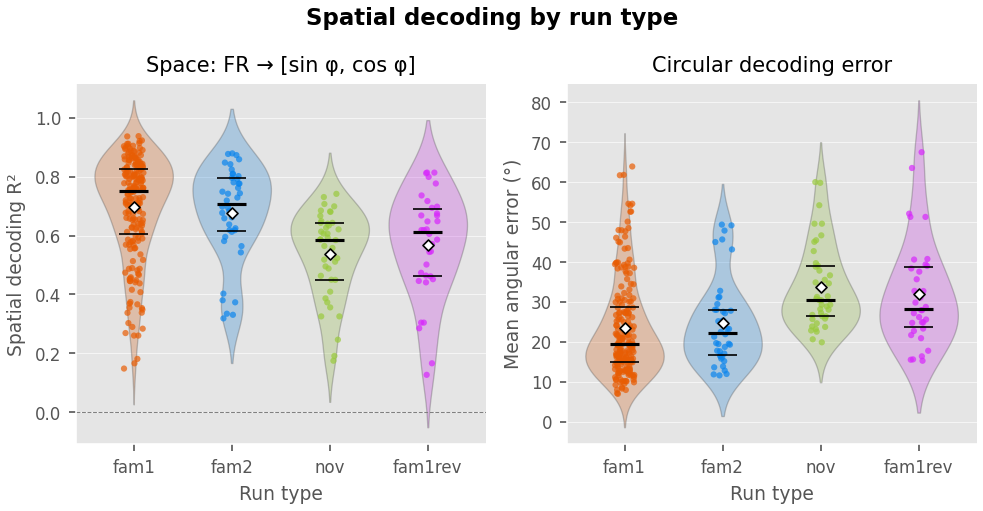

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.5))

# Left: Space R²
ax = axes[0]
sns.violinplot(data=df, x="run_type", y="space_r2", hue="run_type",
               order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
               inner=None, alpha=0.3, legend=False, ax=ax)
sns.stripplot(data=df, x="run_type", y="space_r2", hue="run_type",
              order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
              size=3, alpha=0.7, jitter=True, legend=False, ax=ax)
annotate_violins(ax, df, "run_type", "space_r2", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Spatial decoding R²")
ax.set_title("Space: FR → [sin φ, cos φ]")
ax.axhline(0, color="grey", ls="--", lw=0.5)

# Right: Angular error
ax = axes[1]
sns.violinplot(data=df, x="run_type", y="angular_error", hue="run_type",
               order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
               inner=None, alpha=0.3, legend=False, ax=ax)
sns.stripplot(data=df, x="run_type", y="angular_error", hue="run_type",
              order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
              size=3, alpha=0.7, jitter=True, legend=False, ax=ax)
annotate_violins(ax, df, "run_type", "angular_error", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Mean angular error (°)")
ax.set_title("Circular decoding error")

fig.suptitle("Spatial decoding by run type", fontweight="bold")
plt.tight_layout()
fig.savefig(fig_path / "space_decoding_by_run_type.pdf")
plt.show()

## 3. Temporal Decoding R² by Run Type

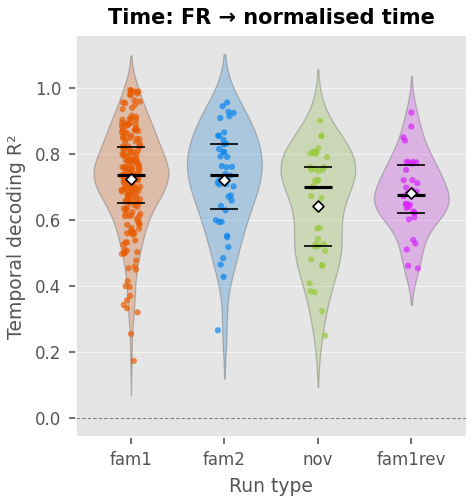

In [17]:
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.5))

sns.violinplot(data=df, x="run_type", y="time_r2", hue="run_type",
               order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
               inner=None, alpha=0.3, legend=False, ax=ax)
sns.stripplot(data=df, x="run_type", y="time_r2", hue="run_type",
              order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
              size=3, alpha=0.7, jitter=True, legend=False, ax=ax)
annotate_violins(ax, df, "run_type", "time_r2", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Temporal decoding R²")
ax.set_title("Time: FR → normalised time", fontweight="bold")
ax.axhline(0, color="grey", ls="--", lw=0.5)
plt.tight_layout()
fig.savefig(fig_path / "time_decoding_by_run_type.pdf")
plt.show()

## 4. Space vs Time Decoding (Scatter)

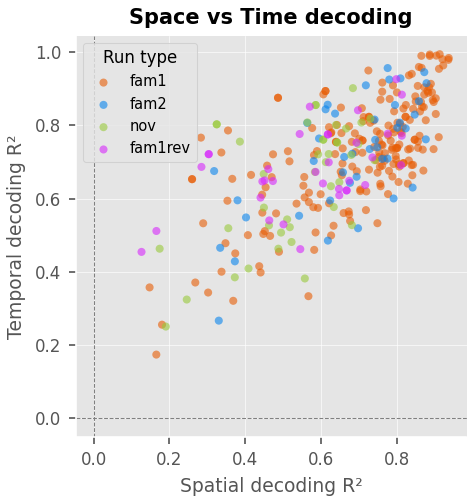

In [18]:
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.5))

for rt in RUN_TYPE_ORDER:
    sub = df[df["run_type"] == rt]
    ax.scatter(sub["space_r2"], sub["time_r2"],
               color=RUN_TYPE_COLORS[rt], label=rt, s=15, alpha=0.6, edgecolors="none")

ax.set_xlabel("Spatial decoding R²")
ax.set_ylabel("Temporal decoding R²")
ax.set_title("Space vs Time decoding", fontweight="bold")
ax.axhline(0, color="grey", ls="--", lw=0.5)
ax.axvline(0, color="grey", ls="--", lw=0.5)
ax.legend(title="Run type", fontsize=7, title_fontsize=8)
plt.tight_layout()
fig.savefig(fig_path / "space_vs_time_scatter.pdf")
plt.show()

## 5. Decoding by Genotype × Age Group

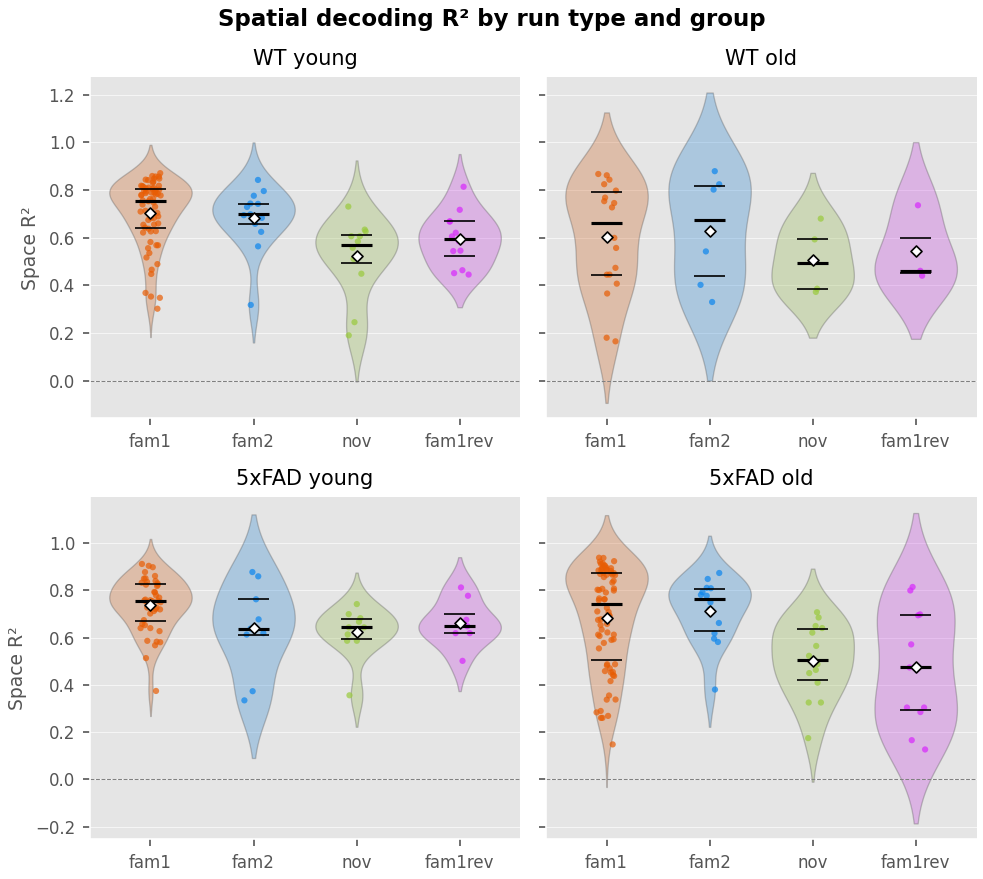

In [19]:
# Faceted: space and time decoding by run type, split by group
fig, axes = plt.subplots(2, 2, figsize=(PlotStyle.FULL_WIDTH, 6), sharey="row")
fig.suptitle("Spatial decoding R² by run type and group", fontweight="bold")

for idx, grp in enumerate(GROUP_ORDER):
    ax = axes.flat[idx]
    sub = df[df["group"] == grp]
    sns.violinplot(data=sub, x="run_type", y="space_r2", hue="run_type",
                   order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
                   inner=None, alpha=0.3, legend=False, ax=ax)
    sns.stripplot(data=sub, x="run_type", y="space_r2", hue="run_type",
                  order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
                  size=3, alpha=0.7, jitter=True, legend=False, ax=ax)
    annotate_violins(ax, sub, "run_type", "space_r2", RUN_TYPE_ORDER)
    ax.set_title(grp.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("Space R²" if idx % 2 == 0 else "")
    ax.axhline(0, color="grey", ls="--", lw=0.5)

plt.tight_layout()
fig.savefig(fig_path / "space_decoding_by_group.pdf")
plt.show()

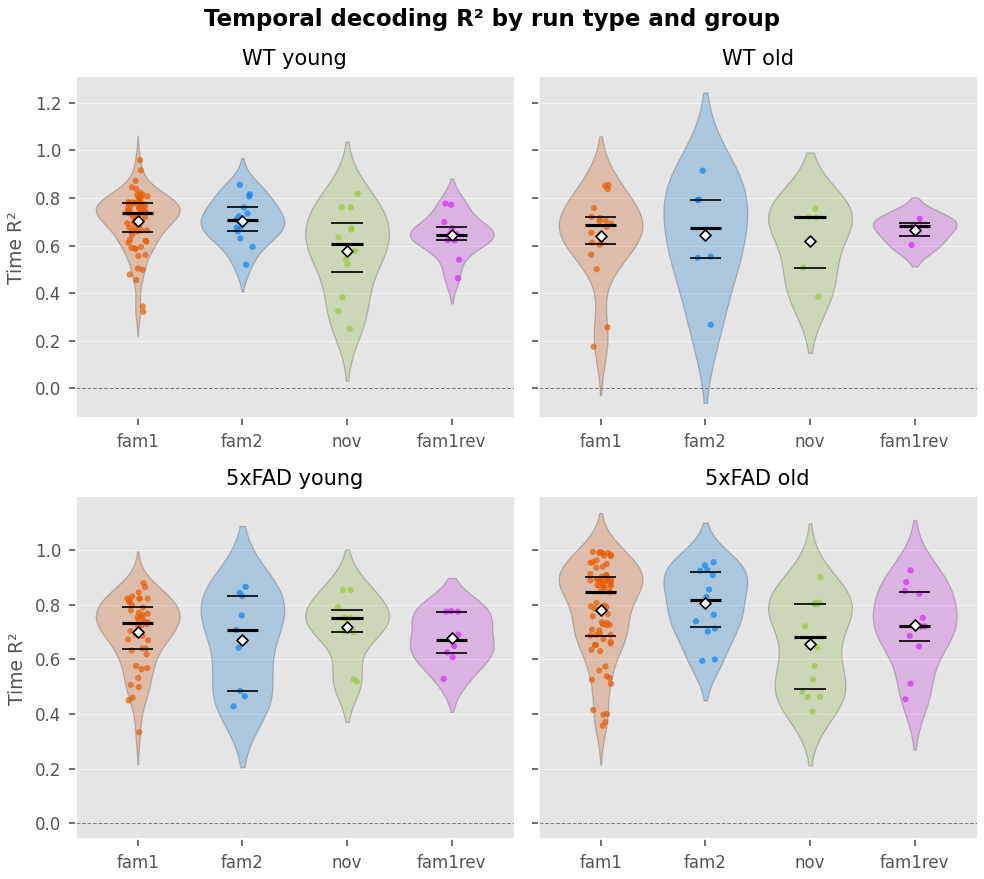

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(PlotStyle.FULL_WIDTH, 6), sharey="row")
fig.suptitle("Temporal decoding R² by run type and group", fontweight="bold")

for idx, grp in enumerate(GROUP_ORDER):
    ax = axes.flat[idx]
    sub = df[df["group"] == grp]
    sns.violinplot(data=sub, x="run_type", y="time_r2", hue="run_type",
                   order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
                   inner=None, alpha=0.3, legend=False, ax=ax)
    sns.stripplot(data=sub, x="run_type", y="time_r2", hue="run_type",
                  order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
                  size=3, alpha=0.7, jitter=True, legend=False, ax=ax)
    annotate_violins(ax, sub, "run_type", "time_r2", RUN_TYPE_ORDER)
    ax.set_title(grp.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("Time R²" if idx % 2 == 0 else "")
    ax.axhline(0, color="grey", ls="--", lw=0.5)

plt.tight_layout()
fig.savefig(fig_path / "time_decoding_by_group.pdf")
plt.show()

## 6. Decoding R² vs Number of Neurons

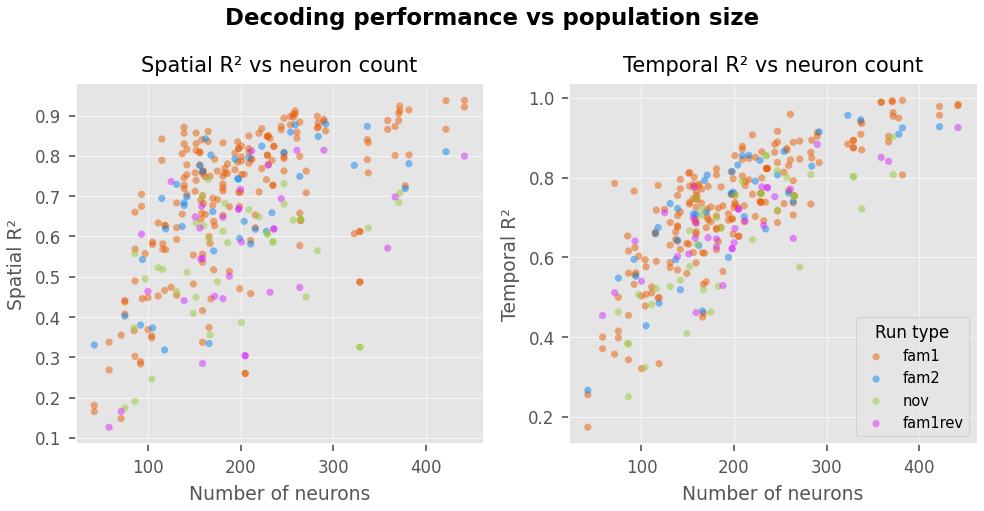

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.5))

for ax, metric, label in zip(axes, ["space_r2", "time_r2"],
                              ["Spatial R²", "Temporal R²"]):
    for rt in RUN_TYPE_ORDER:
        sub = df[df["run_type"] == rt]
        ax.scatter(sub["n_neurons"], sub[metric],
                   color=RUN_TYPE_COLORS[rt], label=rt, s=12, alpha=0.5, edgecolors="none")
    ax.set_xlabel("Number of neurons")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs neuron count")

axes[1].legend(title="Run type", fontsize=7, title_fontsize=8)
fig.suptitle("Decoding performance vs population size", fontweight="bold")
plt.tight_layout()
fig.savefig(fig_path / "decoding_vs_n_neurons.pdf")
plt.show()

## 7. Example Decoding Traces

One example per run type: true vs predicted angular position and normalised time.

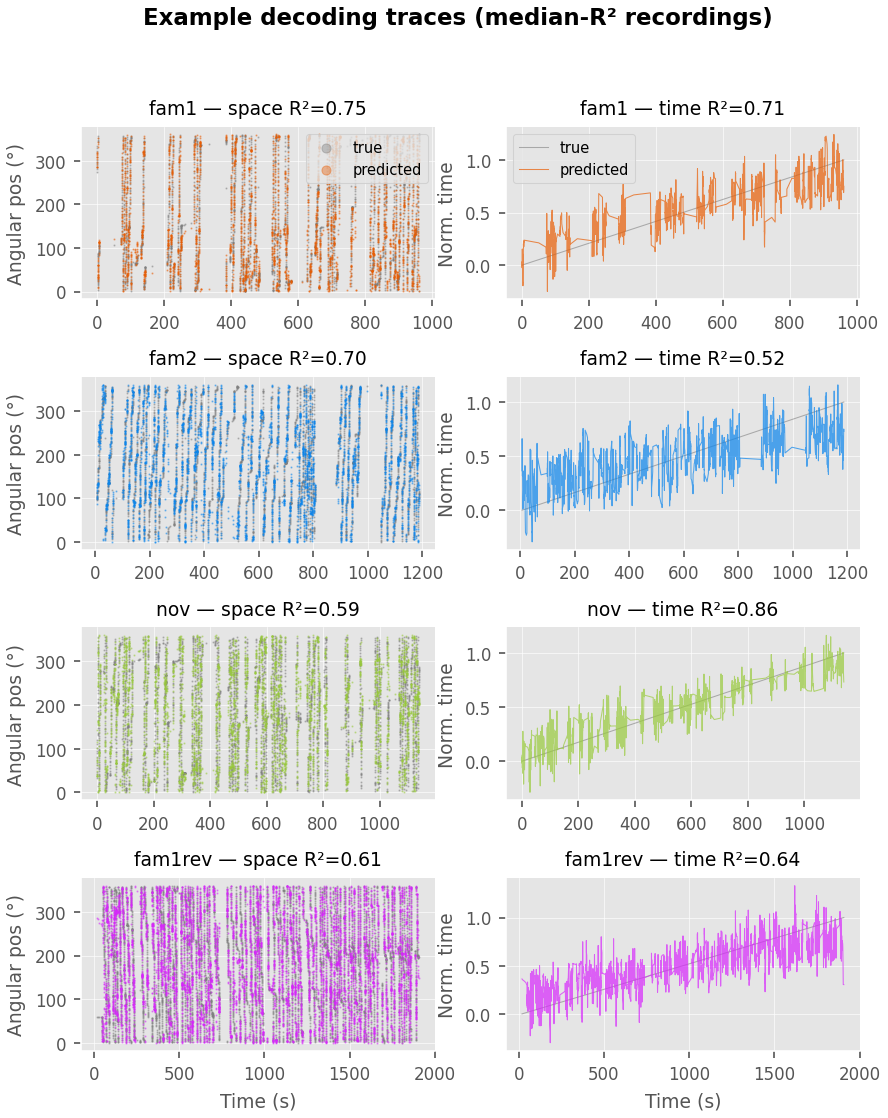

In [22]:
# Pick one representative recording per run type (closest to median space R²)
examples = {}
for rt in RUN_TYPE_ORDER:
    sub = df[df["run_type"] == rt]
    med = sub["space_r2"].median()
    best_idx = (sub["space_r2"] - med).abs().idxmin()
    examples[rt] = sub.loc[best_idx]

fig, axes = plt.subplots(len(RUN_TYPE_ORDER), 2, figsize=(PlotStyle.FULL_WIDTH, 8))

for row_idx, rt in enumerate(RUN_TYPE_ORDER):
    rec = examples[rt]
    subject = Animals(rec["subject"])
    fov, session, run = int(rec["fov"]), rec["session"], rec["run"]

    # Reload data for this recording
    firing_rates, phi, time, _, _, _ = mice.load_firing_rates(
        subject, fov, session, run,
        only_moving=ONLY_MOVING, bins_compress=BINS_COMPRESS,
        bins_smoothing=BINS_SMOOTHING, bins_phi=BINS_PHI,
    )
    valid = ~np.isnan(phi)
    fr = firing_rates[valid]
    phi_v = phi[valid]
    time_v = time[valid]
    time_norm = (time_v - time_v.min()) / (time_v.max() - time_v.min())

    # Spatial decoding
    phi_rad = np.deg2rad(phi_v)
    y_space = np.column_stack([np.sin(phi_rad), np.cos(phi_rad)])
    y_space_pred = decode_cv(fr, y_space, N_FOLDS)
    phi_pred = np.rad2deg(np.arctan2(y_space_pred[:, 0], y_space_pred[:, 1])) % 360

    # Time decoding
    y_time_pred = decode_cv(fr, time_norm, N_FOLDS)

    # Plot space
    ax = axes[row_idx, 0]
    ax.scatter(time_v, phi_v, s=0.3, alpha=0.4, color="grey", label="true", rasterized=True)
    ax.scatter(time_v, phi_pred, s=0.3, alpha=0.4, color=RUN_TYPE_COLORS[rt],
               label="predicted", rasterized=True)
    ax.set_ylabel("Angular pos (°)")
    ax.set_title(f"{rt} — space R²={rec['space_r2']:.2f}", fontsize=9)
    if row_idx == 0:
        ax.legend(markerscale=8, fontsize=7, loc="upper right")
    if row_idx == len(RUN_TYPE_ORDER) - 1:
        ax.set_xlabel("Time (s)")

    # Plot time
    ax = axes[row_idx, 1]
    ax.plot(time_v, time_norm, color="grey", lw=0.5, alpha=0.6, label="true")
    ax.plot(time_v, y_time_pred, color=RUN_TYPE_COLORS[rt], lw=0.5, alpha=0.7, label="predicted")
    ax.set_ylabel("Norm. time")
    ax.set_title(f"{rt} — time R²={rec['time_r2']:.2f}", fontsize=9)
    if row_idx == 0:
        ax.legend(fontsize=7, loc="upper left")
    if row_idx == len(RUN_TYPE_ORDER) - 1:
        ax.set_xlabel("Time (s)")

fig.suptitle("Example decoding traces (median-R² recordings)", fontweight="bold")
fig.subplots_adjust(hspace=0.45)
fig.savefig(fig_path / "example_decoding_traces.pdf")
plt.show()

## 8. Summary Table

In [24]:
summary_rows = []
for rt in RUN_TYPE_ORDER:
    sub = df[df["run_type"] == rt]
    for metric, label in [("space_r2", "Space R²"), ("angular_error", "Ang. error (°)"),
                           ("time_r2", "Time R²")]:
        vals = sub[metric]
        q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
        summary_rows.append({
            "Run type": rt, "Metric": label, "n": len(vals),
            "Median [Q1, Q3]": f"{med:.3f} [{q1:.3f}, {q3:.3f}]",
            "Mean ± SD": f"{vals.mean():.3f} ± {vals.std():.3f}",
        })

summary = pd.DataFrame(summary_rows)
summary

,Run type,Metric,n,"Median [Q1, Q3]",Mean ± SD
0,fam1,Space R²,204,"0.751 [0.605, 0.826]",0.696 ± 0.176
1,fam1,Ang. error (°),204,"19.462 [14.898, 28.772]",23.397 ± 12.087
2,fam1,Time R²,204,"0.738 [0.653, 0.823]",0.725 ± 0.152
3,fam2,Space R²,42,"0.709 [0.614, 0.795]",0.676 ± 0.160
4,fam2,Ang. error (°),42,"22.237 [16.748, 28.063]",24.701 ± 10.739
5,fam2,Time R²,42,"0.737 [0.633, 0.831]",0.722 ± 0.155
6,nov,Space R²,41,"0.586 [0.450, 0.643]",0.537 ± 0.147
7,nov,Ang. error (°),41,"30.470 [26.432, 39.069]",33.868 ± 10.494
8,nov,Time R²,41,"0.699 [0.522, 0.761]",0.644 ± 0.164
9,fam1rev,Space R²,34,"0.612 [0.462, 0.689]",0.568 ± 0.180
